# Feature engineering

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

from heart_failure.config.config import (
    INTERIM_DATA_DIR, PROCESSED_DATA_DIR, HEART_DISEASE, SEX
)
from heart_failure.dataset import split_data
from heart_failure.config.features import RANDOM_STATE, TE_CV, TARGET_CORR_THRESHOLD
from heart_failure.features import select_by_vif, get_fe_pipeline
from heart_failure.plots import plot_corr_matrix, kdeplot_features_by_target

In [22]:
df = pd.read_csv(INTERIM_DATA_DIR / "heart.csv")

y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

X_train, y_train, X_val, y_val, X_test, y_test = split_data(
    X, y, stratify_func=lambda X, y: pd.concat([X[[SEX]], y], axis=1)
)

### Feature implementing

In [23]:
cv = StratifiedKFold(n_splits=TE_CV, shuffle=True, random_state=RANDOM_STATE)
fe_pipeline = get_fe_pipeline(cv, n_bins=8)

In [24]:
X_train = fe_pipeline.fit_transform(X_train, y_train)
X_test = fe_pipeline.transform(X_test)

In [25]:
X_train.head()

,target_encoder__RestingECG,target_encoder__ChestPainType,target_encoder__ST_Slope,binarizer__Age,binarizer__Cholesterol,binarizer__MaxHR,binary_encoder__Sex,binary_encoder__FastingBS,binary_encoder__ExerciseAngina,remainder__RestingBP,...,remainder__Age_MaxHR_ratio,remainder__Oldpeak_ChestPainType_te,remainder__Oldpeak_Cholesterol_ST_Slope_te,remainder__MaxHR_RestingECG_te,remainder__Age_Cholesterol_Sex_te,remainder__ChestPainType_Sex_te,remainder__ST_Slope_Sex_te,remainder__FastingBS_ST_Slope_te,remainder__FastingBS_ChestPainType_te,remainder__FastingBS_ExerciseAngina_te
839,0.518974,0.158438,0.847055,0.0,1.0,3.0,1.0,0.0,0.0,135.0,...,0.310606,0.081867,0.792238,0.618826,0.426938,0.206661,0.900820,0.805747,0.121224,0.250968
351,0.638348,0.782036,0.182399,1.0,4.0,4.0,1.0,0.0,1.0,140.0,...,0.307143,0.833492,0.611060,0.542095,0.661229,0.828384,0.229814,0.130530,0.698837,0.834543
398,0.526223,0.805471,0.193831,3.0,3.0,2.0,1.0,1.0,1.0,165.0,...,0.426230,0.843779,0.596987,0.599322,0.780132,0.837741,0.257855,0.415644,0.958592,0.921032
563,0.626761,0.790451,0.845560,5.0,6.0,6.0,1.0,1.0,1.0,144.0,...,0.356250,0.933698,0.912481,0.267969,0.658700,0.829748,0.894383,0.974480,0.937159,0.926778
190,0.626761,0.790451,0.172154,1.0,6.0,2.0,1.0,0.0,0.0,180.0,...,0.383333,0.584768,0.112236,0.663341,1.000000,0.829748,0.235258,0.139357,0.726525,0.245693


In [26]:
X_train.isna().sum().sort_values(ascending=False).head()

target_encoder__RestingECG       0
target_encoder__ChestPainType    0
target_encoder__ST_Slope         0
binarizer__Age                   0
binarizer__Cholesterol           0
dtype: int64

In [27]:
X_test.isna().sum().sort_values(ascending=False).head()

target_encoder__RestingECG       0
target_encoder__ChestPainType    0
target_encoder__ST_Slope         0
binarizer__Age                   0
binarizer__Cholesterol           0
dtype: int64

### Feature correlation

In [28]:
train = X_train.merge(y_train, left_index=True, right_index=True)
corr_df = train.corr()

In [29]:
plot_corr_matrix(corr_df, width=800, height=800, fontsize=9)

Multicollinearity is present. When we calculate gender target encoding (ex.) into bins of some other feature, the probability of class 1 appearing can be repeated across splits by different features. Therefore, they are highly correlated with each other.

The features ChestPainType (te) and FastingBS_ChestPainType (te); ST_Slope (te) and FastingBS_ST_Slope are also highly correlated. This is explained by the fact that FastingBS is not a significant indicator of the disease, but simply represents the age group most susceptible to the disease.

In [30]:
low_correlated = corr_df[corr_df[HEART_DISEASE].abs() < TARGET_CORR_THRESHOLD].index.to_list()
low_correlated

['target_encoder__RestingECG',
 'binarizer__Cholesterol',
 'remainder__RestingBP']

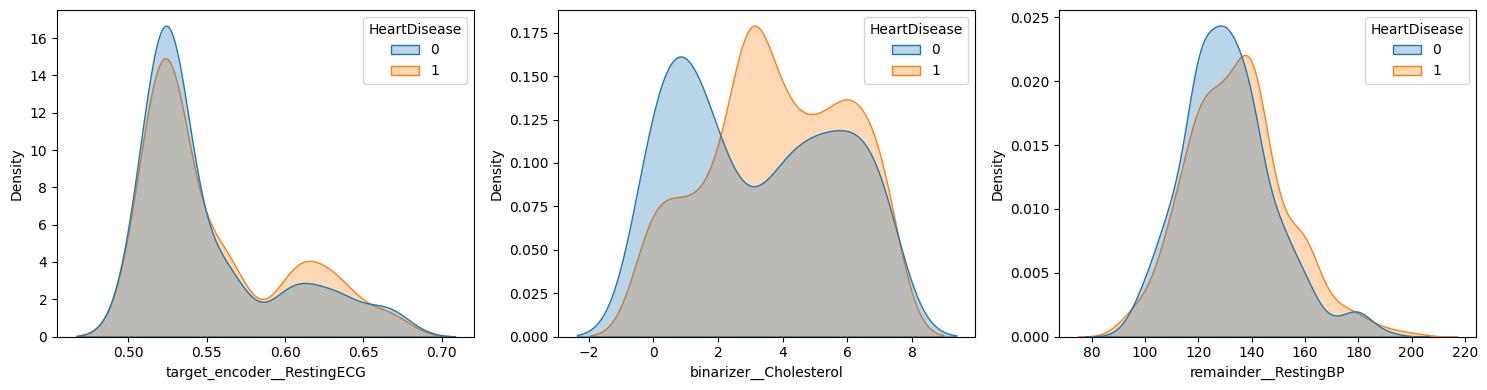

In [31]:
kdeplot_features_by_target(train, low_correlated, HEART_DISEASE)

For RestingECG, the correlation was expected to be small (the percentages initially didn't vary much across categories). RestingBP, in its original form, had no effect, so everything is clear here.

The cholesterol z-score was indeed unsuccessful. However, with binning, the class distributions clearly differ, but not so much as to create a significant correlation. This feature can be retained.

In [32]:
low_correlated.remove('binarizer__Cholesterol')
X_train = X_train.drop(columns=low_correlated)
X_test = X_test.drop(columns=low_correlated)

In [33]:
remaining_cols, drop_order = select_by_vif(X_train, y_train)
drop_order

target_encoder__ChestPainType             1092.595152
target_encoder__ST_Slope                   436.060691
remainder__FastingBS_ChestPainType_te      254.583826
remainder__FastingBS_ST_Slope_te           121.777085
remainder__FastingBS_ExerciseAngina_te      74.411546
remainder__Age_MaxHR_ratio                  57.787965
remainder__Oldpeak_ChestPainType_te         40.102074
remainder__ST_Slope_Sex_te                  25.537769
remainder__Age_Cholesterol_Sex_te           13.381483
dtype: float64

In [34]:
remaining_cols

['binarizer__Age',
 'binarizer__Cholesterol',
 'binarizer__MaxHR',
 'binary_encoder__Sex',
 'binary_encoder__FastingBS',
 'binary_encoder__ExerciseAngina',
 'remainder__Oldpeak',
 'remainder__conjunctive_rules',
 'remainder__Oldpeak_Cholesterol_ST_Slope_te',
 'remainder__MaxHR_RestingECG_te',
 'remainder__ChestPainType_Sex_te']

All intergroup features are discarded as duplicate signals. Only the transformed initial features and conjunctive rules remain.

In [35]:
train = X_train[remaining_cols].merge(y_train, left_index=True, right_index=True)
corr_df = train.corr()
plot_corr_matrix(corr_df, width=600, height=600, fontsize=9)

In [36]:
pd.Series(remaining_cols).to_csv(PROCESSED_DATA_DIR / 'remaining_cols.csv', index=False)

### Binned features

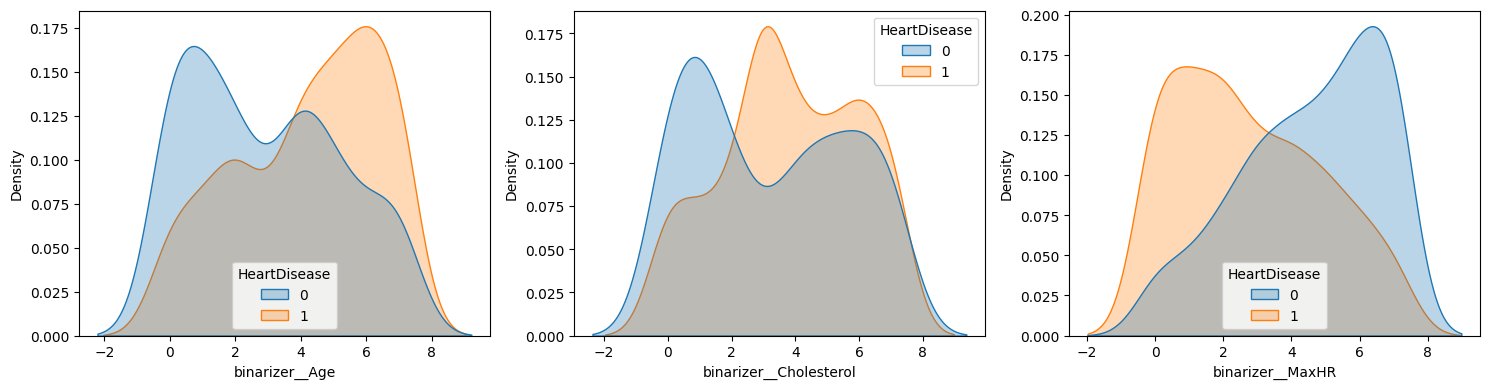

In [37]:
binned = X_train.columns[X_train.columns.str.startswith("binarizer__")]
kdeplot_features_by_target(train, binned, HEART_DISEASE)

Target correlation with binned features has increased. Class distributions do not overlap. Binning definitely helps for cholesterol, which has abnormally high values. Age and MaxHR also have rare high/low values. This helps at least linear models.

In [38]:
X_train_raw = df.loc[X_train.index]

Age: False
Cholesterol: False
MaxHR: False


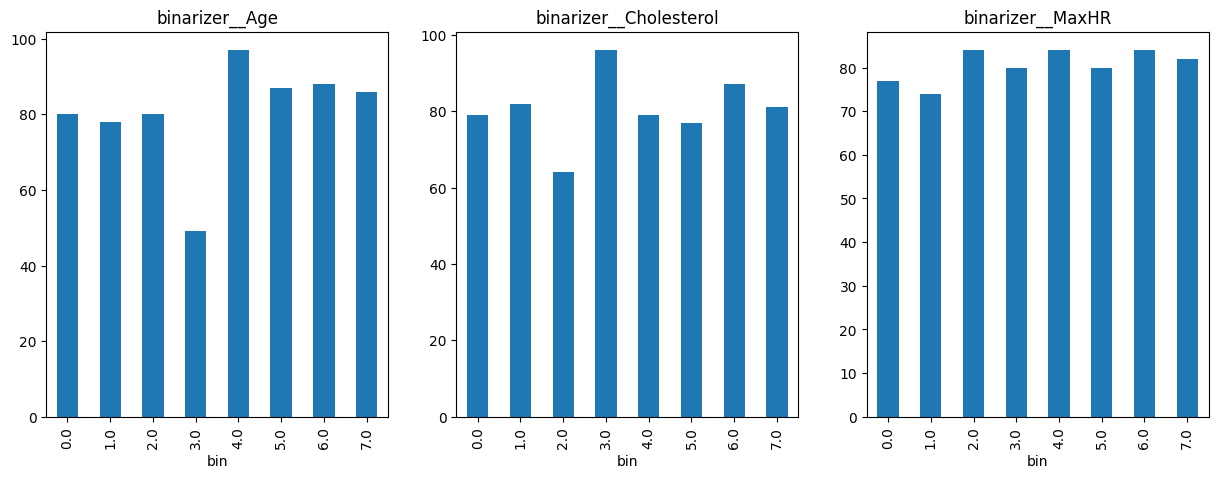

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for col, ax in zip(binned, axes):
    raw_cal = col.removeprefix("binarizer__")
    tmp = pd.DataFrame({raw_cal: X_train_raw[raw_cal], "bin": X_train[col]})
    tmp["bin"].value_counts().sort_index().plot(kind="bar", ax=ax)
    ax.set_title(col)
    unique = tmp.groupby(raw_cal)["bin"].nunique().sort_values(ascending=False)
    print(f"{raw_cal}:", unique.iloc[0] > 1)

In [40]:
binner = fe_pipeline.named_steps["preprocessor"].named_transformers_["binarizer"]
edges = pd.Series(binner.bin_edges_)
edges.index = binned
edges

binarizer__Age            [28.0, 42.0, 48.0, 52.0, 54.0, 57.0, 60.0, 64....
binarizer__Cholesterol    [85.0, 194.0, 216.0, 230.0, 234.0, 248.0, 269....
binarizer__MaxHR          [60.0, 106.0, 120.0, 128.0, 138.0, 146.0, 155....
dtype: object

The bin situation is more or less normal. Of course, there are some bins that are rare, but not that much. With 10 bins, the situation was worse, as there were several bins with relatively few values.